# ***Ⅱ. 텍스트 데이터 처리***

## ***1. 텍스트 자료의 표현***
텍스트 자료는 크게 **정형화된 자료**와 **비정형화된 자료**로 나눌 수 있습니다.
- **정형화된 자료**: 규격화된 형식을 가진 자료 (예: 영화 평점, 스프레드시트 데이터)
- **비정형화된 자료**: 자유 형식으로 되어 있어 규격화되지 않은 자료 (예: 영화 감상 후기, SNS 댓글, 이미지, 영상)

In [13]:
# 예시
movie_rating = "9.0"  # 정형화된 텍스트 자료
movie_review = """
시각적으로나 청각적으로나 아름답지 않은 것이 없다.
10번을 봐도 질리지 않는 영화, 10번을 들어도 질리지 않는 노래들!
1965년에 만든 영화라는 게 믿기지 않을 정도로 명작이다.
"""  # 비정형화된 텍스트 자료

print("영화 평점:", movie_rating)
print("영화 감상 후기:", movie_review)

영화 평점: 9.0
영화 감상 후기: 
시각적으로나 청각적으로나 아름답지 않은 것이 없다.
10번을 봐도 질리지 않는 영화, 10번을 들어도 질리지 않는 노래들!
1965년에 만든 영화라는 게 믿기지 않을 정도로 명작이다.



| 구분    | 정형화된 텍스트 자료                  | 비정형화된 텍스트 자료                           |
| ----- | ---------------------------- | -------------------------------------- |
| 특징    | 규격화된 표로 나타낼 수 있는 자료          | 규격화되지 않아 자료 가공이 어렵다                    |
| 자료 관리 | 삽입, 수정 등 관리 용이               | 관리 어려움                                 |
| 정보 해석 | 원하는 정보를 쉽게 찾고 비교 가능          | 규칙성을 찾기 어렵고 해석 힘듦                      |
| 수집    | 규격화된 상태로 수집 가능               | 대량 수집 가능하지만 비정형적                       |
| 예시 1  | 영화 평점: 9.0, 8.5, 7.2         | 영화 감상 후기: “영상미가 뛰어나지만 배우 연기가 아쉬워요.”    |
| 예시 2  | 학생 성적표: 수학 95, 영어 88, 과학 90  | 선생님 의견: “수학에 흥미를 갖고 열심히 합니다” |
| 예시 3  | 직원 근태 기록: 출근 09:00, 퇴근 18:00 | 근무 평가 의견: “출근을 칼같이 하고 퇴근도 칼같이 합니다”           |
| 예시 4  | 매출 데이터: 3월 판매량 1200, 4월 1350 | 매출 분석 의견: “이번달은 장사가 잘 되었네요. 특히 A제품 판매가 두드러졌고, B제품은 다소 감소했습니다”  |
| 예시 5  | 설문조사 객관식: 만족도 4/5             | 설문조사 주관식: “너무 좋아요~~~”                |


## ***텍스트 자료를 수치화(벡터화)하기***
1) 정형화된 텍스트 수치 성분을 그대로 벡터화
2) 비정형화된 텍스트를 수치 형태로 변환
3) 비정형화된 텍스트를 원핫 벡터로 표현
4) 비정형화된 텍스트의 빈도수 표현

### ***벡터의 개념***
- 여러 속성을 한 번에 나타낸 것 → 벡터
- 예: 키(cm)와 몸무게(kg)로 사람 A, B를 나타내기
- 이처럼 **순서를 정하여 수를 나열한 것**을 **벡터**라고 하며, 기호로 $\vec{a}$ 와 같이 나타냅니다
- 벡터 $\vec{a} = (a_1, a_2, \dots, a_n)$ 일 때, 각각의 $a_1, a_2, \dots, a_n$을 **벡터의 성분**이라고 합니다


### ***두 2차원 벡터 사이의 거리***
$d = \|\vec{A} - \vec{B}\| = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$

In [30]:
vec_a = (180, 70)
vec_b = (160, 70)

# 벡터의 크기 계산
import math

def vector_magnitude(v):
    return math.sqrt(sum([x**2 for x in v]))

print("A 벡터 크기:", vector_magnitude(vec_a))
print("B 벡터 크기:", vector_magnitude(vec_b))

# 두 벡터 사이 거리
def vector_distance(v1, v2):
    return math.sqrt(sum([(x-y)**2 for x,y in zip(v1,v2)]))

print("A와 B 사이 거리:", vector_distance(vec_a, vec_b))

A 벡터 크기: 193.13207915827965
B 벡터 크기: 174.64249196572982
A와 B 사이 거리: 20.0


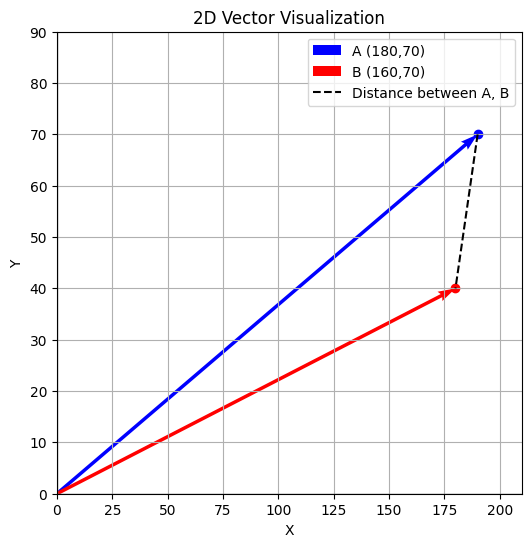

In [35]:
import matplotlib.pyplot as plt

def draw_vector(vec_a, vec_b):

    # 원점 기준 벡터 그리기
    plt.figure(figsize=(6,6))
    plt.axhline(0, color='gray', linewidth=1)  # x축
    plt.axvline(0, color='gray', linewidth=1)  # y축

    # 벡터 A
    plt.quiver(0, 0, vec_a[0], vec_a[1], angles='xy', scale_units='xy', scale=1, color='blue', label='A (180,70)')
    # 벡터 B
    plt.quiver(0, 0, vec_b[0], vec_b[1], angles='xy', scale_units='xy', scale=1, color='red', label='B (160,70)')

    # A와 B 사이 거리 시각화 (선으로 연결)
    plt.plot([vec_a[0], vec_b[0]], [vec_a[1], vec_b[1]], 'k--', label='Distance between A, B')

    # 벡터 위치 표시
    plt.scatter(*vec_a, color='blue')
    plt.scatter(*vec_b, color='red')

    # 범위 및 레이블
    plt.xlim(0, max(vec_a[0],vec_b[0])+20)
    plt.ylim(0, max(vec_a[1],vec_b[1])+20)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('2D Vector Visualization')
    plt.grid(True)
    plt.legend()
    plt.show()

A = (190, 70)
B = (180, 40)
draw_vector(A, B)

### ***3차원 벡터***
- 벡터의 성분 축이 3개 입니다
- 여기까지는 우리의 세계에서 시각화가 가능합니다

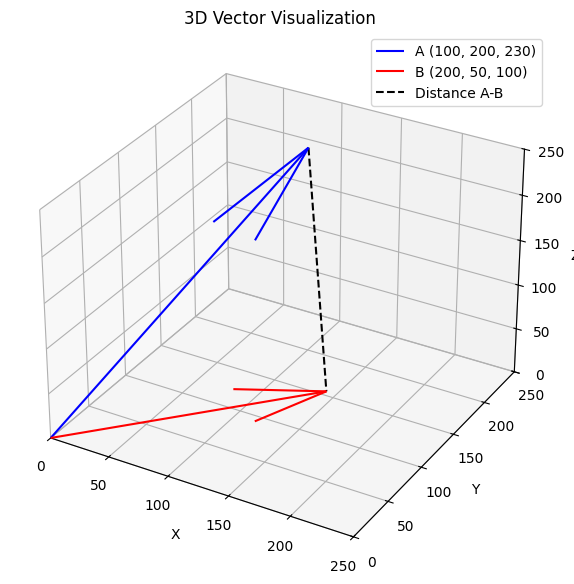

In [42]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D 지원
import numpy as np

def draw_vector_3d(vec_a, vec_b):
    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111, projection='3d')

    # 원점 기준 벡터
    ax.quiver(0, 0, 0, vec_a[0], vec_a[1], vec_a[2], color='blue', label=f'A {vec_a}')
    ax.quiver(0, 0, 0, vec_b[0], vec_b[1], vec_b[2], color='red', label=f'B {vec_b}')

    # 두 벡터 사이 거리 직선 (선분)
    ax.plot([vec_a[0], vec_b[0]], [vec_a[1], vec_b[1]], [vec_a[2], vec_b[2]], 'k--', label='Distance A-B')

    # 범위 및 레이블
    max_range = np.array([vec_a, vec_b]).max() + 20
    ax.set_xlim(0, max_range)
    ax.set_ylim(0, max_range)
    ax.set_zlim(0, max_range)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('3D Vector Visualization')
    ax.legend()
    plt.show()

# 3차원 벡터 예제
A = (100, 200, 230)
B = (200, 50, 100)
draw_vector_3d(A, B)

### ***4차원 벡터... 표현!!!***
- 우리 공간상에서는 표현 불가능합니다
- 그러나 점의 크기를 표현하여 시각화할 수 있습니다

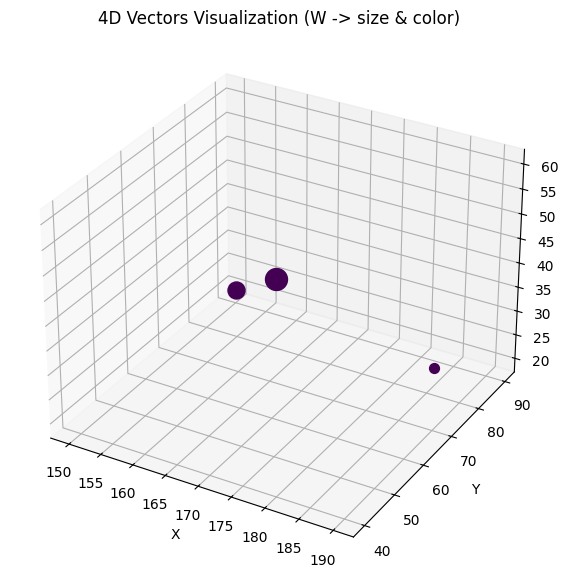

In [43]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 예제 4차원 벡터
vecs = [
    (190, 70, 30, 10),
    (180, 40, 60, 50),
    (150, 90, 20, 30)
]

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

for v in vecs:
    x, y, z, w = v
    ax.scatter(x, y, z, s=w*5, c=[w/100], cmap='viridis')  # w를 크기와 색상으로 표현

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('4D Vectors Visualization (W -> size & color)')
plt.show()

### ***5차원 벡터?!?! 표현!!!***
- 시각화 가능한 모든 수단을 끌어올려 표현해봅니다

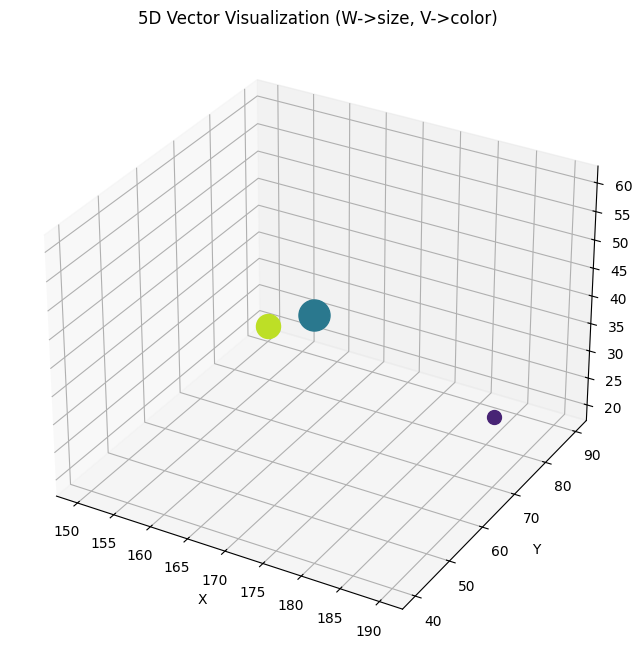

In [47]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 예제 5차원 벡터: (x, y, z, w, v)
vectors = [
    (190, 70, 30, 10, 0.1),
    (180, 40, 60, 50, 0.4),
    (150, 90, 20, 30, 0.9)
]

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

for vec in vectors:
    x, y, z, w, v = vec
    # w -> 점 크기, v -> 색상
    ax.scatter(x, y, z, s=w*10, c=[v], cmap='viridis', vmin=0, vmax=1, depthshade=True)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('5D Vector Visualization (W->size, V->color)')
plt.show()

### ***6차원 벡터!!! 이제 그만...***
- 벡터는 많은 차원을 표현할 수 있음을 이해하면 됩니다
- 대신 이번에는 6차원 벡터간의 거리를 계산해보겠습니다

In [48]:
import math

# 6차원 벡터 예제
A = (190, 70, 30, 10, 0.2, 5)
B = (180, 40, 60, 50, 0.8, 10)

# 유클리드 거리 계산 함수
def vector_distance(v1, v2):
    return math.sqrt(sum((x - y) ** 2 for x, y in zip(v1, v2)))

dist = vector_distance(A, B)
print("6차원 벡터 A와 B 사이 거리:", dist)

6차원 벡터 A와 B 사이 거리: 59.374742104703074


---
#### ***3차원 벡터 거리***
$
\vec{A} = (x_1, y_1, z_1), \quad \vec{B} = (x_2, y_2, z_2)
$

$
d(\vec{A}, \vec{B}) = \|\vec{A} - \vec{B}\| = \sqrt{ (x_2 - x_1)^2 + (y_2 - y_1)^2 + (z_2 - z_1)^2 }
$

---

#### ***4차원 벡터 거리***
$
\vec{A} = (x_1, y_1, z_1, w_1), \quad \vec{B} = (x_2, y_2, z_2, w_2)
$

$
d(\vec{A}, \vec{B}) = \|\vec{A} - \vec{B}\| = \sqrt{ (x_2 - x_1)^2 + (y_2 - y_1)^2 + (z_2 - z_1)^2 + (w_2 - w_1)^2 }
$

---

#### 5차원 벡터 거리***
$
\vec{A} = (x_1, y_1, z_1, w_1, v_1), \quad \vec{B} = (x_2, y_2, z_2, w_2, v_2)
$

$
d(\vec{A}, \vec{B}) = \|\vec{A} - \vec{B}\| = \sqrt{ (x_2 - x_1)^2 + (y_2 - y_1)^2 + (z_2 - z_1)^2 + (w_2 - w_1)^2 + (v_2 - v_1)^2 }
$

---

#### ***6차원 벡터 거리***
$
\vec{A} = (x_1, y_1, z_1, w_1, v_1, u_1), \quad \vec{B} = (x_2, y_2, z_2, w_2, v_2, u_2)
$

$
d(\vec{A}, \vec{B}) = \|\vec{A} - \vec{B}\| = \sqrt{ (x_2 - x_1)^2 + (y_2 - y_1)^2 + (z_2 - z_1)^2 + (w_2 - w_1)^2 + (v_2 - v_1)^2 + (u_2 - u_1)^2 }
$

---

#### ***n차원 일반화***
$
\vec{A} = (a_1, a_2, \dots, a_n), \quad \vec{B} = (b_1, b_2, \dots, b_n)
$

$
d(\vec{A}, \vec{B}) = \|\vec{A} - \vec{B}\| = \sqrt{ \sum_{i=1}^{n} (b_i - a_i)^2 }
$

---

## ***벡터의 연산도구 numpy***
- 파이썬의 numpy라는 라이브러리는 벡터연산에 강력한 도구 입니다
- 아래는 numpy를 사용하지 않고 벡터연산을 하는 예제와 numpy를 사용한 벡터연산 예제입니다
- 두 가지 방법 모두 동일한 결과이긴 합니다
- 그러나 그 속도가 다릅니다

In [82]:
import math

# 어제와 오늘 판매량
yesterday = (3, 1, 4)
today     = (3, 4, 1)

# 벡터 덧셈
total_sales = tuple([y + t for y, t in zip(yesterday, today)])
print("이틀 동안 총 판매량:", total_sales)

# 벡터 뺄셈
diff_sales = tuple([t - y for t, y in zip(today, yesterday)])
print("오늘 판매량 변화:", diff_sales)

# 벡터 크기 (길이)
magnitude_today = math.sqrt(sum([x**2 for x in today]))
print("오늘 판매량 벡터 크기:", magnitude_today)

# 두 벡터 사이 거리
distance = math.sqrt(sum([(t - y)**2 for t, y in zip(today, yesterday)]))
print("어제와 오늘 판매량 벡터 거리:", distance)

이틀 동안 총 판매량: (6, 5, 5)
오늘 판매량 변화: (0, 3, -3)
오늘 판매량 벡터 크기: 5.0990195135927845
어제와 오늘 판매량 벡터 거리: 4.242640687119285


In [83]:
import numpy as np

# 어제와 오늘 옷 판매량
yesterday = np.array([3, 1, 4])  # 모자, 바지, 셔츠
today     = np.array([3, 4, 1])

# 벡터 덧셈 (이틀 동안 판매량)
total_sales = yesterday + today
print("이틀 동안 총 판매량:", total_sales)

# 벡터 뺄셈 (오늘-어제)
diff_sales = today - yesterday
print("오늘 판매량 변화:", diff_sales)

# 벡터 크기(길이)
magnitude_today = np.linalg.norm(today)
print("오늘 판매량 벡터 크기:", magnitude_today)

# 벡터 거리
distance = np.linalg.norm(today - yesterday)
print("어제와 오늘 판매량 벡터 거리:", distance)

이틀 동안 총 판매량: [6 5 5]
오늘 판매량 변화: [ 0  3 -3]
오늘 판매량 벡터 크기: 5.0990195135927845
어제와 오늘 판매량 벡터 거리: 4.242640687119285


### ***반복 테스트를 통한 numpy 성능 확인***
- 큰 차원의 벡터로 반복 테스트하면 성능의 차이를 알 수 있습니다

In [ ]:
import random
import math
import time

random.seed(42)

total_duration = 0

for i in range(1000):
    start = time.perf_counter()

    # 100차원 벡터 생성 (0~10 사이 랜덤 정수)
    vec1 = tuple([random.randint(0, 10) for _ in range(100)])
    vec2 = tuple([random.randint(0, 10) for _ in range(100)])

    # 벡터 덧셈
    sum_vec = tuple([x + y for x, y in zip(vec1, vec2)])

    # 벡터 뺄셈
    diff_vec = tuple([x - y for x, y in zip(vec1, vec2)])

    # 벡터 크기
    magnitude_vec1 = math.sqrt(sum([x**2 for x in vec1]))
    magnitude_vec2 = math.sqrt(sum([x**2 for x in vec2]))

    # 두 벡터 사이 거리
    distance = math.sqrt(sum([(x - y)**2 for x, y in zip(vec1, vec2)]))

    end = time.perf_counter()

    duration = end - start
    total_duration += duration

    print("벡터1 크기:", magnitude_vec1)
    print("벡터2 크기:", magnitude_vec2)
    print("두 벡터 사이 거리:", distance)
    print()

print('총 연산시간', total_duration)

In [ ]:
import numpy as np
import time

np.random.seed(42)
total_duration = 0

for i in range(1000):
    start = time.perf_counter()

    # 100차원 벡터 생성 (0~10 사이 랜덤 정수)
    vec1 = np.random.randint(0, 11, size=100)
    vec2 = np.random.randint(0, 11, size=100)

    # 벡터 덧셈, 뺄셈
    sum_vec = vec1 + vec2
    diff_vec = vec1 - vec2

    # 벡터 크기
    magnitude_vec1 = np.linalg.norm(vec1)
    magnitude_vec2 = np.linalg.norm(vec2)

    # 두 벡터 사이 거리
    distance = np.linalg.norm(vec1 - vec2)

    end = time.perf_counter()
    total_duration += end - start

    print("벡터1 크기:", magnitude_vec1)
    print("벡터2 크기:", magnitude_vec2)
    print("두 벡터 사이 거리:", distance)

print('총 연산시간 (numpy):', total_duration)

## ***비정형화된 텍스트의 벡터화***
- 텍스트를 수치로 표현하면 분석이 가능해집니다.
- 비정형화된 텍스트 자료를 효과적으로 분석하기 위해서는 **텍스트를 수치화**하여 나타내야 합니다
- 하지만 상품 평점과 같이 단일 수치로만 평가하면 정보 손실이 발생할 수 있습니다
  - 리뷰 텍스트를 평점으로만 표현
  - 똑같은 4.3/5 점수이지만 내용은 전혀 다른 텍스트

In [36]:
# 같은 평점 4점/5점
review1_text = "컬러가 정말 예쁘고 사용감도 만족스러워요. 가격은 좀 비싸지만 그만큼 가치 있음."
review2_text = "가격이 너무 비싸요. 근데 뭐 비싼값은 하네요. 세련되고 맘에는 듭니다. 근데 가격이 좀..."
rating1 = 4.3
rating2 = 4.3

print("평점만 비교:")
print("리뷰1 평점:", rating1)
print("리뷰2 평점:", rating2)

print("\n텍스트 비교:")
print("리뷰1 텍스트:", review1_text)
print("리뷰2 텍스트:", review2_text)

평점만 비교:
리뷰1 평점: 4.3
리뷰2 평점: 4.3

텍스트 비교:
리뷰1 텍스트: 컬러가 정말 예쁘고 사용감도 만족스러워요. 가격은 좀 비싸지만 그만큼 가치 있음.
리뷰2 텍스트: 가격이 너무 비싸요. 근데 뭐 비싼값은 하네요. 세련되고 맘에는 듭니다. 근데 가격이 좀...


### ***벡터를 이용한 비정형 텍스트 표현***
- 자료를 수로 표현하면서 여러 정보를 함께 포함할 수 있는 방법을 생각해 봅니다
- 예를 들어 영화 평가에서 긍정 단어를 1, 부정 단어를 -1, 언급 없음은 0으로 표현할 수 있습니다

In [20]:
# 예시 문장
review = "컬러는 정말 예쁜데 가격이 너무 비싸요."
# 단어 기준 벡터 (색상, 가격, 사용감)
# '예쁘다' → 1, '비싸다' → -1, '사용감 언급 없음' → 0
vector_review = (1, -1, 0)
print("벡터화된 리뷰:", vector_review)

벡터화된 리뷰: (1, -1, 0)


- 긍정의 정도, 부정의 정도에 따라 벡터값을 다르게 할 수 있습니다

In [14]:
# 예시 문장
review1 = "컬러는 정말 예쁜데 가격이 너무 비싸요."
# 단어 기준 벡터 (색상, 가격, 사용감)
# '예쁘다' → 1, '비싸다' → -1, '정말 예쁘다' → 2, '너무 비싸다' → -2,'사용감 언급 없음' → 0
vector_review = (2, -2, 0)
print("벡터화된 리뷰1:", vector_review)


review2 = "컬러는 예쁜데 가격이 비싸요."
# 단어 기준 벡터 (색상, 가격, 사용감)
# '예쁘다' → 1, '비싸다' → -1, '정말 예쁘다' → 2, '너무 비싸다' → -2,'사용감 언급 없음' → 0
vector_review = (1, -1, 0)
print("벡터화된 리뷰2:", vector_review)

벡터화된 리뷰1: (2, -2, 0)
벡터화된 리뷰2: (1, -1, 0)


## ***원핫 벡터***
- 단어의 존재 여부만 판단해봅니다
- 색상 관련 언급 여부
- 가격 관련 언급 여부
- 사용감 관련 언급 여부
- 기타 성분도 추가 가능합니다

In [58]:
review1 = "컬러는 정말 예쁜데 가격이 너무 비싸요."

import re

def review_to_onehot(review):
    # 색상 관련
    color_pattern = r"(예쁘\w*|이쁘\w*|색감\w*)"
    
    # 가격 관련
    price_pattern = r"(비싸\w*|싸고\w*|저렴\w*)"
    
    # 사용감 관련
    usage_pattern = r"(편하\w*|불편\w*|부드러\w*|촉감|느낌|사용감)"

    # my_pattern = r"(세련\w*|촌스럽\w*|독특\w*)"   # 실습: 새로운 벡터 성분을 추가해봅시다
    
    vector = [
        1 if re.search(color_pattern, review) else 0,  # 색상
        1 if re.search(price_pattern, review) else 0,  # 가격
        1 if re.search(usage_pattern, review) else 0,   # 사용감
        # 1 if re.search(my_pattern, review) else 0   # 실습: 새로운 벡터 성분을 추가해봅시다
    ]
    return vector

review1 = "컬러는 정말 예쁜데 가격이 너무 비싸요."
review2 = "사용감이 편하고 컬러도 예쁘지만 가격이 조금 비싸네요."
review3 = "이거 그냥 그런데 촉감은 부드러워요"

print(review_to_onehot(review1))  # [1, 1, 0]
print(review_to_onehot(review2))  # [1, 1, 1]
print(review_to_onehot(review3))  # [0, 0, 1]

[1, 1, 0]
[1, 1, 1]
[0, 0, 1]


In [29]:
my_review = input('상품평을 입력하세요')
print(review_to_onehot(my_review))

[0, 1, 0, 0]


## ***빈도수 벡터***

In [59]:
review1 = "컬러는 정말 예쁘고 좋은데 가격이 너무 비싸요. 색감이 좋아서 재구매의사 있습니다"
review2 = "사용감이 촉감 좋고 편하고 컬러도 예쁘지만 가격이 조금 비싸네요. 너무 비싸서 다시 구매할지는 모르겠어요"
review3 = "이거 그냥 그런데 편하고 촉감은 부드러워요"

import re

def review_to_countvector(review):
    # 색상 관련
    color_pattern = r"(예쁘\w*|이쁘\w*|색감\w*)"
    
    # 가격 관련
    price_pattern = r"(비싸\w*|싸고\w*|저렴\w*)"
    
    # 사용감 관련
    usage_pattern = r"(편하\w*|불편\w*|부드러\w*|촉감|느낌|사용감)"
    
    # 새로운 성분 예시
    # my_pattern = r"(세련\w*|촌스럽\w*|독특\w*)" # 실습: 디자인 관련한 여러 단어, 접두어를 추가해봅니다
    
    vector = [
        len(re.findall(color_pattern, review)),   # 색상 빈도
        len(re.findall(price_pattern, review)),   # 가격 빈도
        len(re.findall(usage_pattern, review)),   # 사용감 빈도
        # len(re.findall(my_pattern, review))       # 실습: 새로운 성분 빈도
    ]
    return vector

print(review_to_countvector(review1))  # 예: [2, 1, 0]
print(review_to_countvector(review2))  # 예: [1, 2, 3]
print(review_to_countvector(review3))  # 예: [0, 0, 3]

[2, 1, 0]
[1, 2, 3]
[0, 0, 3]


### ***텍스트 자료를 속성 기준으로 벡터화***
- 예시: 단어 '고양이', '사람', '비둘기', '원숭이'를 속성으로 표현
- 속성: (생명체인가?, 하늘을 나는가?, 영장류인가?)
- 이것은 원핫으로 표현하는게 좋을까요? 아니면 빈도수로 표현하는 것이 좋을까요?

In [ ]:
cat = (1, 0, 0)
human = (1, 0, 1)
pigeon = (1, 1, 0)
monkey = (1, 0, 1)

print("고양이 벡터:", cat)
print("사람 벡터:", human)
print("비둘기 벡터:", pigeon)
print("원숭이 벡터:", monkey)

### ***영화 평점데이터 감정 벡터화***
- 단어별 감정 언급 횟수를 벡터로 나타내기
- 연관 단어: 기쁨, 노여움, 슬픔, 즐거움
- 이것은 원핫으로 표현하는게 좋을까요? 아니면 빈도수로 표현하는게 좋을까요?

In [76]:
# 뉴스 댓글 예시
comment1 = """와, 영화 정말 재밌고 관람료가 전혀 아깝지 않습니다
영화 덕분에 행복한 주말이 되었습니다
"""
comment2 = """
스토리는 아쉽지만 배우 연기 때문에 즐거운 관람이었어요.
특히 몇몇 장면은 정말 즐거웠고, 보는 내내 즐거움이 느껴졌습니다.
전체적으로 배우들의 연기 덕분에 즐거움과 기쁨이 연속이었습니다.
추천합니다
"""

comment3 = """
초반에 지루해서 짜증났고, 일부 장면은 제 인생같아서 안타까웠습니다.
몇몇 장면에서는 속상함이 계속 느껴졌고, 슬픔과 안타까움이 반복되었습니다.
마지막 장면에서도 짜증과 분노가 동시에 올라왔습니다.
그걸로 끝이라니 열린결말인가요?
"""
comment4 = """결말은 신나고 흥미진진했지만, 중간에는 화가 날 정도로 답답한 전개였어요.
보다가 잤습니다. 속상해 ㅜㅠㅠ
불면증 있으신분 추천드려요
"""

import re

def comment_to_countvector(comment):
    # 감정 단어 패턴
    joy_pattern   = r"(기쁨\w*|기쁘\w*|행복\w*|재밌\w*|즐거\w*)"
    anger_pattern = r"(노여움\w*|화\w*|짜증\w*|분노\w*|불만\w*)"
    sad_pattern   = r"(슬픔\w*|안타깝\w*|속상\w*|아쉽\w*)"
    fun_pattern   = r"(즐거움\w*|재미\w*|신나\w*|흥미\w*)"
    
    vector = [
        len(re.findall(joy_pattern, comment)),   # 기쁨 빈도
        len(re.findall(anger_pattern, comment)), # 노여움 빈도
        len(re.findall(sad_pattern, comment)),   # 슬픔 빈도
        len(re.findall(fun_pattern, comment))    # 즐거움 빈도
    ]
    return vector

# 결과 확인
print(comment_to_countvector(comment1))
print(comment_to_countvector(comment2))
print(comment_to_countvector(comment3))
print(comment_to_countvector(comment4))

[2, 2, 0, 0]
[5, 0, 1, 2]
[0, 3, 2, 0]
[0, 1, 1, 2]


## ***정리***
- 비정형 텍스트를 벡터화 하는 기초적인 방법에는 크게 아래 2가지가 있습니다
- 원핫 벡터와 빈도수 벡터는 각각 적합한 용도가 있습니다

| 구분        | 원핫 벡터                          | 빈도수 벡터                |
| --------- | ------------------------------ | --------------------- |
| 정의        | 단어/속성 존재 여부만 표시 (있으면 1, 없으면 0) | 단어/속성 등장 횟수를 수치로 표현   |
| 예시 텍스트    | "컬러는 정말 예쁘고 좋은데 가격이 너무 비싸요. 색감이 좋아서 재구매의사 있습니다"          | "컬러는 정말 예쁘고 좋은데 가격이 너무 비싸요. 색감이 좋아서 재구매의사 있습니다" |
| 속성        | 색상, 가격, 사용감                    | 색상, 가격, 사용감           |
| 벡터화 결과    | `[1, 1, 0]`                    | `[2, 1, 0]`   |
| 텍스트 반복 단어 | 반복해도 1로 표시                     | 반복 등장 횟수만큼 값 증가       |
| 장점        | 간단, 속성 존재 확인용                  | 단어 반복/강도까지 반영 가능      |
| 사용 예시     | 제품 리뷰 속성 존재 여부                 | 뉴스 댓글 감정 분석, 리뷰 감정 강도 |
